## 1. Introduction

ชุดข้อมูลนี้เป็นบันทึกการใช้พลังงานไฟฟ้าอย่างละเอียดของบริษัท DAEWOO Steel Co. Ltd ซึ่งตั้งอยู่ในเมืองกวางยาง ประเทศเกาหลีใต้ โดยบริษัทเป็นผู้ผลิตหลักด้านเหล็กม้วน เหล็กแผ่น และแผ่นเหล็ก ส่งผลให้มีการใช้พลังงานในปริมาณสูงและมีความผันผวนอย่างต่อเนื่อง

ข้อมูลดังกล่าวถูกรวบรวมผ่านระบบคลาวด์ และมีการซิงโครไนซ์กับ Korea Electric Power Corporation (KEPCO) ในบริบทของโครงการ InduCognix AI ชุดข้อมูลนี้ถูกนำมาใช้เป็นข้อมูลอ้างอิง (benchmark) สำหรับการพัฒนาเอเจนต์อัจฉริยะด้านอุตสาหกรรมที่สามารถรับรู้และบริหารจัดการพลังงาน (Energy-Aware Industrial Agents) เพื่อคาดการณ์ช่วงเวลาที่มีความต้องการใช้พลังงานสูง (peak demand) และเพิ่มประสิทธิภาพในการจัดตารางการทำงานของเครื่องจักร เพื่อลดต้นทุนการดำเนินงานและลดผลกระทบต่อสิ่งแวดล้อม

---

**รูปแบบข้อมูล (Format):** ไฟล์ CSV ในรูปแบบ Tidy ซึ่งเหมาะสำหรับการประมวลผลด้วยเครื่อง

**ความละเอียดของข้อมูล (Granularity):** บันทึกข้อมูลทุก ๆ 15 นาที

**ช่วงเวลา (Duration):** ครอบคลุมการดำเนินงานตลอดปี พ.ศ. 2561 (2018)

**จำนวนข้อมูล (Total Observations):** 35,040 แถว ครอบคลุม 11 ตัวแปร

**ลักษณะของข้อมูล (Data Characteristics):** ชุดข้อมูลประกอบด้วยตัวแปรทางไฟฟ้าที่มีความสำคัญ เช่น กำลังไฟฟ้า (Active Power), กำลังรีแอคทีฟ (Reactive Power) และตัวประกอบกำลังไฟฟ้า (Power Factor) รวมถึงตัวแปรเชิงหมวดหมู่ เช่น ประเภทโหลด (Load Type) และสถานะของวัน (Week Status) โดยข้อมูลถูกออกแบบให้สามารถนำไปใช้กับโมเดลอนุกรมเวลา เช่น LSTM หรือ Gradient Boosting ได้โดยตรง โดยไม่จำเป็นต้องมีการเตรียมข้อมูลที่ซับซ้อน

In [2]:
import kagglehub

path = kagglehub.dataset_download("haideradnan77/steel-industry-energy-consumption-daewoo-steel-co")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'steel-industry-energy-consumption-daewoo-steel-co' dataset.
Path to dataset files: /kaggle/input/steel-industry-energy-consumption-daewoo-steel-co


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(path + "/Steel_industry_data.csv")
data.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


# Exploratory Data Analysis (EDA)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

In [5]:
data.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


In [6]:
# แปลง 'date' > รูปแบบ datetime และ Set Index
data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y %H:%M')
data.set_index('date', inplace=True)

In [7]:
# แปลงข้อมูลจาก ทุกๆ 15 นาที ให้เป็นค่าเฉลี่ยนรายวันแทน
daily_usage = data['Usage_kWh'].resample('D').mean()
print(f"daily_usage จาก 35040 แถว เหลือแค่ {len(daily_usage)} แถว")

daily_usage จาก 35040 แถว เหลือแค่ 365 แถว


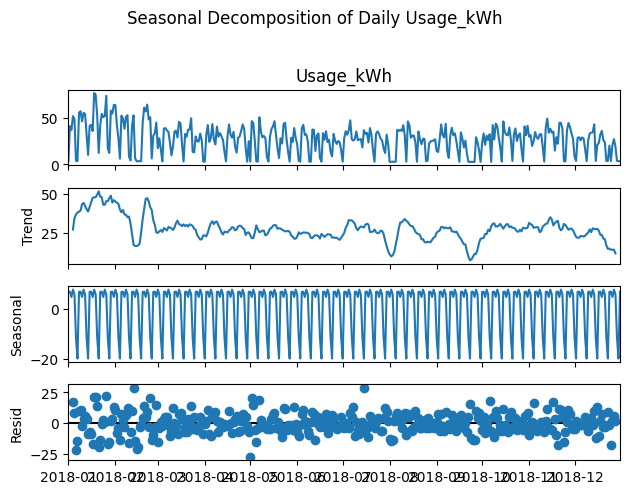

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# ทำ seasonal decomposition
decomposition = seasonal_decompose(
    daily_usage,
    model='additive', # Observed = Trend + Seasonal + Residual (additive)
    period=7 # Period = 7 เนื่องจาก ทำเป็น weekly seasonality (1 week = 7 days)
)

fig = decomposition.plot()
fig.figsize=(12, 10)
plt.suptitle('Seasonal Decomposition of Daily Usage_kWh', y=1.02)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

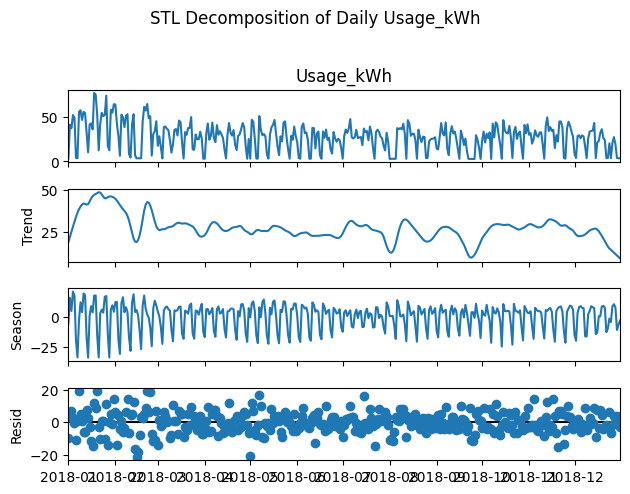

In [9]:
from statsmodels.tsa.seasonal import STL

plt.figure(figsize=(12, 10))

# ทำ Seasonal-Trend decomposition using LOESS (STL)
stl = STL(daily_usage, period=7)
result = stl.fit()
result.plot()

plt.suptitle('STL Decomposition of Daily Usage_kWh', y=1.02)
plt.tight_layout()
plt.show()

ข้อมูลการใช้พลังงานรายวันใน 1 ปี โดยพล็อตออกเป็น 4 กราฟ ได้แก่

1. Observed → ข้อมูลจริง
2. Trend → แนวโน้ม
3. Seasonal → แพทเทิร์นในแต่ละ 1 สัปดาห์
4. Residual → noise
---

จากการเปรียบเทียบผลการแยกองค์ประกอบของ Time Series พบว่า
วิธี seasonal_decompose ให้ค่า seasonal component ที่ค่อนข้างคงที่
เนื่องจากสมมติให้รูปแบบฤดูกาลไม่เปลี่ยนแปลงตามเวลา

ในขณะที่ STL decomposition สามารถสะท้อนความผันผวนของ seasonal
ได้ดีกว่า โดยแสดงให้เห็นว่าความแรงของ seasonal pattern มีการเปลี่ยนแปลง
ในแต่ละช่วงเวลา

อย่างไรก็ตาม trend component ของทั้งสองวิธีมีลักษณะใกล้เคียงกัน
แสดงให้เห็นว่าแนวโน้มหลักของข้อมูลมีความชัดเจนและไม่ขึ้นอยู่กับวิธีการ decomposition มากนัก

# Methodology

> ทำนายการใช้พลังงานด้วยโมเดลต่างๆ พร้อมวัดประสิทธิภาพโมเดลแต่ละตัว

This study applies three different approaches for time series forecasting,
including
- a statistical model (SARIMA)
- a machine learning model (XGBoost)
- a deep learning model (LSTM)

Each model is trained using the same dataset to ensure a fair comparison.

---
The dataset is split into training and testing sets based on time order,

- Train Set: วันที่ 1 ถึง วันที่ 335 (ประมาณ 32,160 แถว)

- Test Set: วันที่ 336 ถึง วันที่ 365 (2,880 แถวสุดท้าย)

In [10]:
# เนื่องจากเป็นข้อมูลที่เป็น time series สามารถแยกด้วย len ได้เลย
usage_kWh = data['Usage_kWh']

# ทุก 15 นาที 1 วันมี 96 แถว, 30 วันมี 2,880 แถว
test_size = 30 * 96
train_data = usage_kWh.iloc[:-test_size]
test_data = usage_kWh.iloc[-test_size:]

print(f"Train: {len(train_data)} rows | Test: {len(test_data)} rows")

Train: 32160 rows | Test: 2880 rows


### 1. **Statistical** : SARIMA
> เนื่องจากมีข้อมูลพลังงานที่ใช้ในหน่วย kWh นั้นมี Pattern ซ้ำรายสัปดาห์ (Seasonal + ARIMA)

(P, D, Q, s) for the seasonal part, where s represents the seasonal period.
- p = ดูอดีตกี่วัน = 1
- d = ทำ differencing กี่ครั้ง = 1
- q = ใช้ error ย้อนหลัง = 1
- s = คิดเป็นรายวัน = 96

Format: ใช้ข้อมูลเป็น Univariate Series (แถวเดียวเรียงกันไป) Stationarity: อาจต้องทำ Differencing (ค่า $d$ และ $D$) เพื่อให้ข้อมูลนิ่งSeasonality: คุณต้องระบุค่า $s$ (Seasonal period) ให้ชัดเจน เช่น ถ้าจะจับ Cycle รายวัน ต้องใช้ $s = 96$ (เพราะ $15 \text{ min} \times 96 = 24 \text{ hours}$)

In [11]:
train_sarima = train_data
test_sarima = test_data

In [12]:
from statsmodels.tsa.stattools import adfuller

# ทำ Seasonal Diff
df_diff = train_sarima.diff(96).dropna()

# Check
result = adfuller(df_diff)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -20.563232256003406
p-value: 0.0


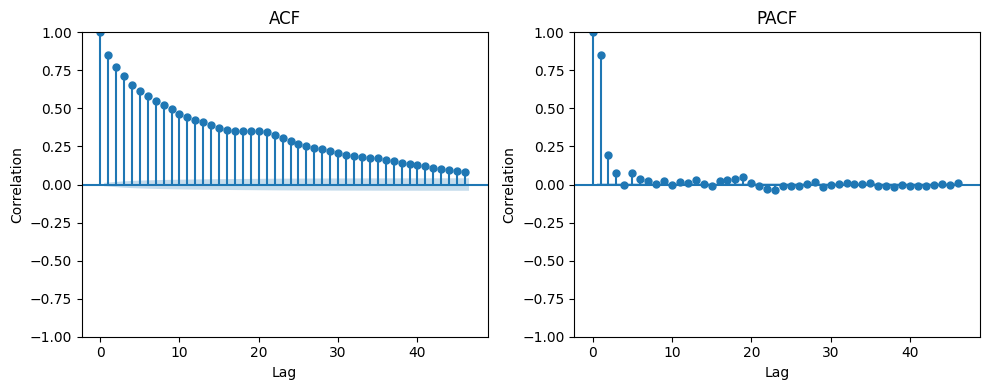

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_acf(df_diff, ax=axes[0])
axes[0].set_title('ACF')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlation')

plot_pacf(df_diff, ax=axes[1])
axes[1].set_title('PACF')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

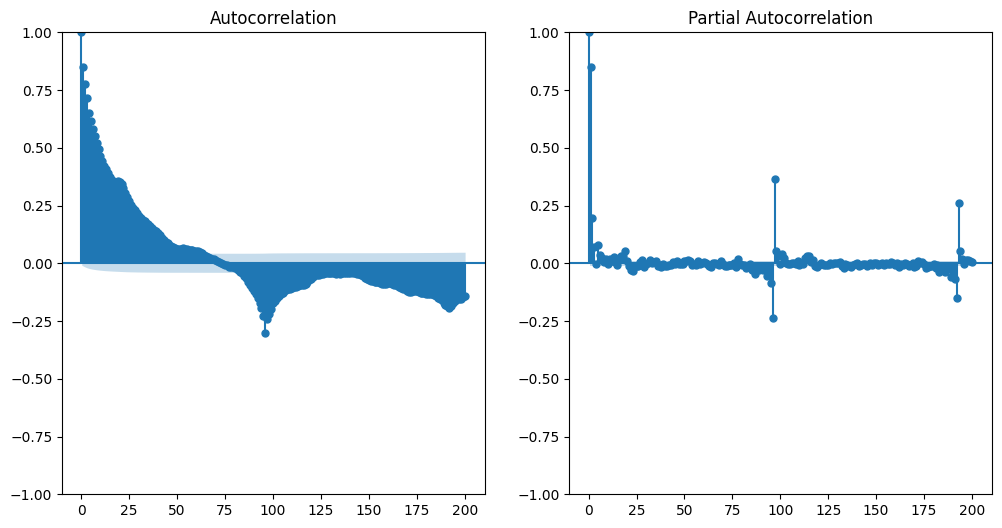

In [14]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
plot_acf(df_diff, lags=200, ax=ax[0])
plot_pacf(df_diff, lags=200, ax=ax[1])
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train_sarima,
    order=(2, 0, 1),
    seasonal_order=(1, 1, 1, 96),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

> จากโค้ดด้านบนจะเห็นว่า ใช้ s = 96 ตรงจุดนี้จะใช้ เวลาและ ram ในการคำนวณเยอะมากๆ จึงจะทำการลดการคำนวณข้อมูลรายวัน ให้เป็นการทำนายโดยคิดเป็นข้อมูลรายสัปดาห์

In [15]:
# ปรับแต่ง SARIMAX ให้เทรนเร็วขึ้น (ลดไป daily aggregation + seasonal=7)
train_sarima_daily = train_sarima.resample('D').mean()
test_sarima_daily = test_sarima.resample('D').mean()

print(f"Daily SARIMA: {len(train_sarima_daily)} train rows, {len(test_sarima_daily)} test rows")

Daily SARIMA: 335 train rows, 30 test rows


In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ใช้ seasonal_order=(1,1,1,7) แทน 96
model = SARIMAX(
    train_sarima_daily,
    order=(1,0,1),
    seasonal_order=(0,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(maxiter=300, disp=False)

In [45]:
results = model.fit()

print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         Usage_kWh   No. Observations:                  335
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 7)   Log Likelihood               -1187.546
Date:                           Tue, 31 Mar 2026   AIC                           2383.091
Time:                                   13:58:16   BIC                           2398.152
Sample:                               01-01-2018   HQIC                          2389.106
                                    - 12-01-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5838      0.091      6.418      0.000       0.405       0.762
ma.L1         -0.1396      0.105     -1.329

In [46]:
# จำนวนวันใน test
steps = len(test_sarima_daily)

sarima_forecast = results.get_forecast(steps=steps)

sarima_pred_daily = sarima_forecast.predicted_mean
conf_int = sarima_forecast.conf_int()

### 2. **Machine Learning**: XGboost

XGBoost is used as a machine learning approach for forecasting.
Since machine learning models cannot directly handle time series data,
lag features are created to transform the data into a supervised learning format.

Previous observations are used as input features to predict future values.
The model is trained on the training dataset and evaluated on the testing dataset.

In [47]:
# ทำ Feature Engineering

def create_features(series):
    # ทำ lag dataset
    df = pd.DataFrame(series)
    df.columns = ['y']

    # -----------------
    # 1. Lag features
    # -----------------
    for i in range(1, 8):
        df[f'lag_{i}'] = df['y'].shift(i)

    # -----------------
    # 2. Rolling stats
    # -----------------
    df['rolling_mean_7'] = df['y'].rolling(7).mean()
    df['rolling_std_7'] = df['y'].rolling(7).std()

    # -----------------
    # 3. Time features
    # -----------------

    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

    # -----------------
    # 4. Trend
    # -----------------
    df['trend'] = range(len(df))

    df.dropna(inplace=True)

    return df

In [48]:
train_df = create_features(train_data)
test_df = create_features(test_data)

X_train = train_df.drop(columns=['y'])
y_train = train_df['y']

X_test = test_df.drop(columns=['y'])
y_test = test_df['y']

In [49]:
from xgboost import XGBRegressor

model = XGBRegressor()

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = model.predict(X_test)

### 3. **Deep Learning**: LSTM

LSTM (Long Short-Term Memory) is used as a deep learning approach
for time series forecasting. It is designed to capture temporal dependencies
in sequential data.

The input data is first normalized and then transformed into sequences
using a sliding window approach. The model is trained using the training data
and used to predict future values in the testing set.

Validation Set: หากจะเทรน LSTM หรือ XGBoost ให้แม่นๆ แนะนำให้แบ่ง train_data ออกมาอีกส่วนหนึ่ง (เช่น 15 วันสุดท้ายของ Train) เพื่อใช้เป็นตัววัดผลระหว่างเทรน (Validation) เพื่อป้องกันการ Overfit ครับ

In [23]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [24]:
# เนื่องจากเป็นข้อมูลที่เป็น time series สามารถแยกด้วย len ได้เลย
usage_kWh = data['Usage_kWh']

# ทุก 15 นาที 1 วันมี 96 แถว, 30 วันมี 2,880 แถว
test_size = 30 * 96
train_data = usage_kWh.iloc[:-test_size]
test_data = usage_kWh.iloc[-test_size:]

print(f"Train: {len(train_data)} rows | Test: {len(test_data)} rows")

Train: 32160 rows | Test: 2880 rows


In [25]:
series = data['Usage_kWh']

# split ก่อน (ห้าม scale ก่อน split!)
test_size = 30 * 96

train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

In [26]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data.values.reshape(-1,1))
test_scaled = scaler.transform(test_data.values.reshape(-1,1))

In [27]:
def create_sequences(data, n_steps=96):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i-n_steps:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

In [28]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(96,1)),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [30]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0136 - val_loss: 0.0081
Epoch 2/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0086 - val_loss: 0.0069
Epoch 3/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0077 - val_loss: 0.0065
Epoch 4/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0074 - val_loss: 0.0062
Epoch 5/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0071 - val_loss: 0.0062
Epoch 6/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0068 - val_loss: 0.0059
Epoch 7/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0066 - val_loss: 0.0058
Epoch 8/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0065 - val_loss: 0.0055
Epoch 9/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 10/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0062 - val_loss: 0.0052
Epoch 11/15
902/902 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0062 - val_loss: 0.0049
Epoch 12/15
902/902 ━━━━━━━━━━━

In [31]:
y_pred = model.predict(X_test)

87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [32]:
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# 4. Model Comparison and Evaluation
Model performance is evaluated using 3 metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
def evaluate_model(y_true, y_pred):
    """
    Evaluate model performance using MAE, RMSE, and MAPE
    """

    # MAE
    mae = mean_absolute_error(y_true, y_pred)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE (handle zero division)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

    return {
        "MAE": mae,
        "RMSE": str(rmse),
        "MAPE": str(mape)
    }

SARIMA Performance:
{'MAE': 7.90363073271643, 'RMSE': '10.826685766962258', 'MAPE': '116.2385680689923'}


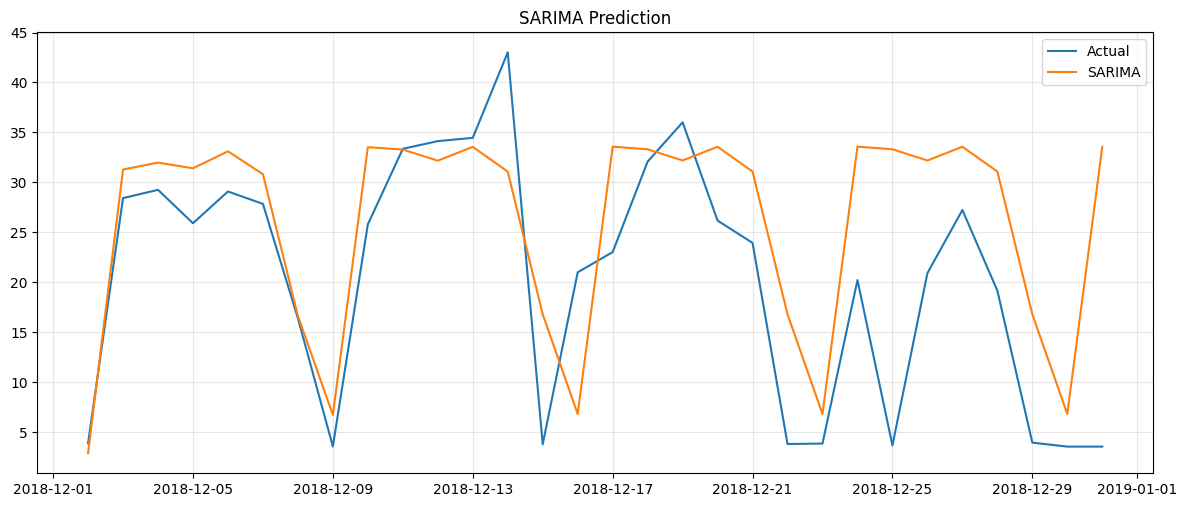

In [53]:
sarima_metrics = evaluate_model(test_sarima_daily, sarima_pred_daily)

print("SARIMA Performance:")
print(sarima_metrics)

plt.figure(figsize=(12,5))
plt.plot(test_sarima_daily, label='Actual')
plt.plot(sarima_pred_daily, label='SARIMA')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.title("SARIMA Prediction")
plt.show()

XGBoost Performance:
{'MAE': 1.7368601888569648, 'RMSE': '3.737720946306607', 'MAPE': '10.225056528177069'}


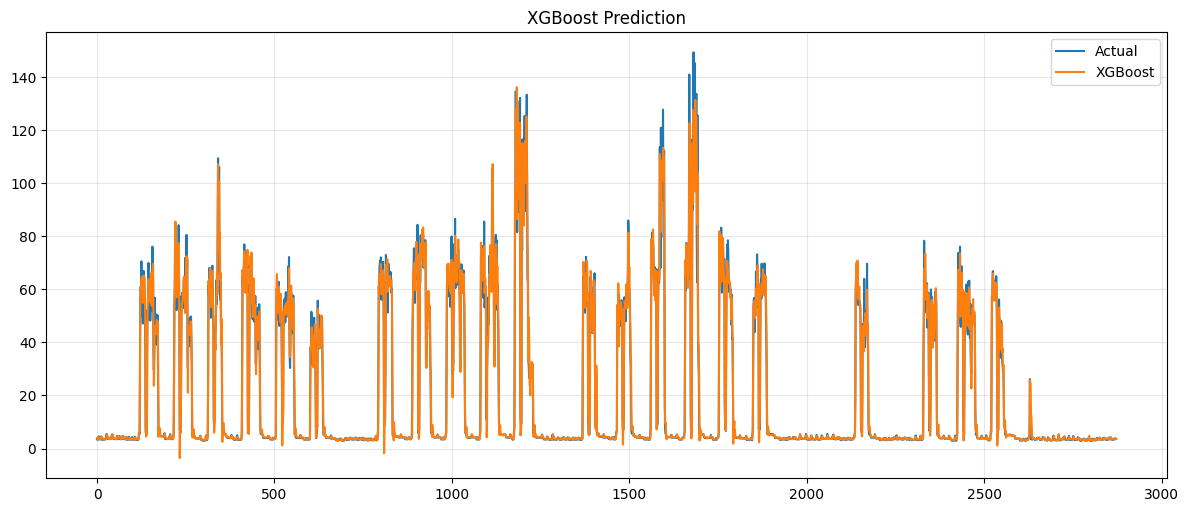

In [51]:
xgb_metrics = evaluate_model(y_test, xgb_pred)

print("XGBoost Performance:")
print(xgb_metrics)

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(xgb_pred, label='XGBoost')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.title("XGBoost Prediction")
plt.show()

LSTM Performance:
{'MAE': 3.9928655350366715, 'RMSE': '7.508524110092513', 'MAPE': '32.32644157570771'}


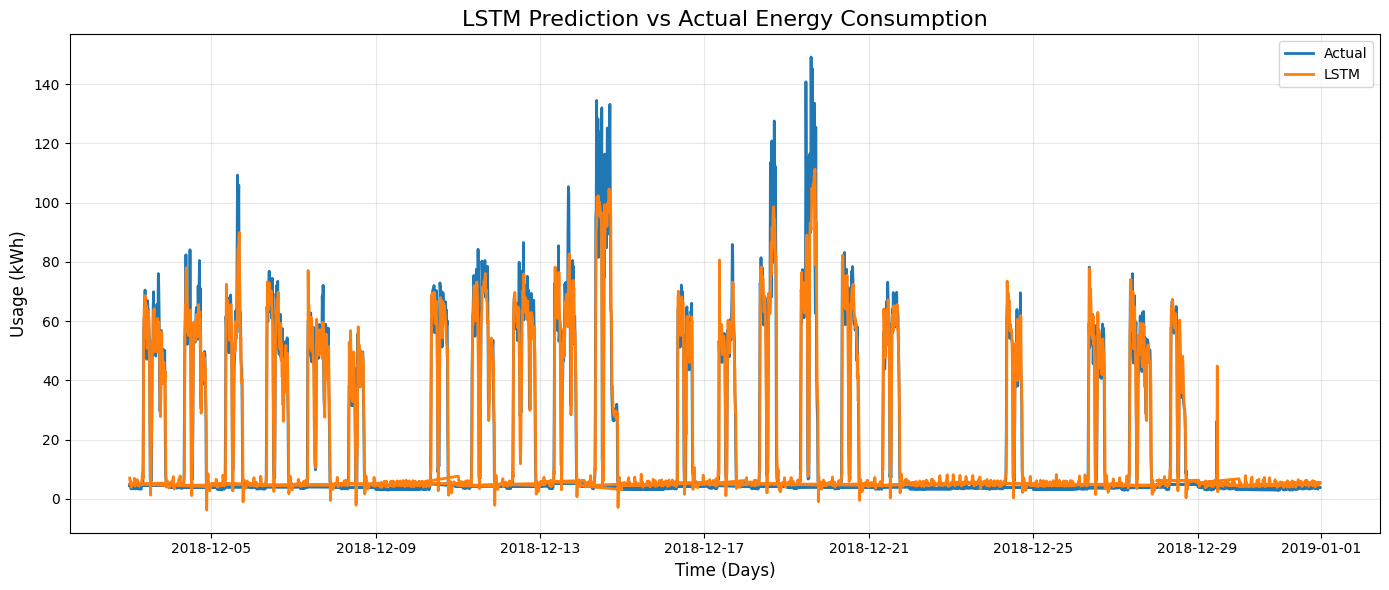

In [62]:
lstm_metrics = evaluate_model(y_test_inv, y_pred_inv)

print("LSTM Performance:")
print(lstm_metrics)

# ต้อง align index (เพราะ sequence ทำให้หายไป 96 จุดแรก)
test_index = test_data.index[96:]

plt.figure(figsize=(14,6))

plt.plot(test_index, y_test_inv, label='Actual', linewidth=2)
plt.plot(test_index, y_pred_inv, label='LSTM', linewidth=2)

plt.title('LSTM Prediction vs Actual Energy Consumption', fontsize=16)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Usage (kWh)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Results and Discussion  
> เปรียบเทียบผลลัพธ์ที่ได้จากการทำนายด้วยทั้ง 3 โมเดล

In [54]:
results = pd.DataFrame({
    "SARIMA": sarima_metrics,
    "XGBoost": xgb_metrics,
    "LSTM": lstm_metrics
}).T

print(results)

              MAE                RMSE                MAPE
SARIMA   7.903631  10.826685766962258   116.2385680689923
XGBoost   1.73686   3.737720946306607  10.225056528177069
LSTM     3.992866   7.508524110092513   32.32644157570771


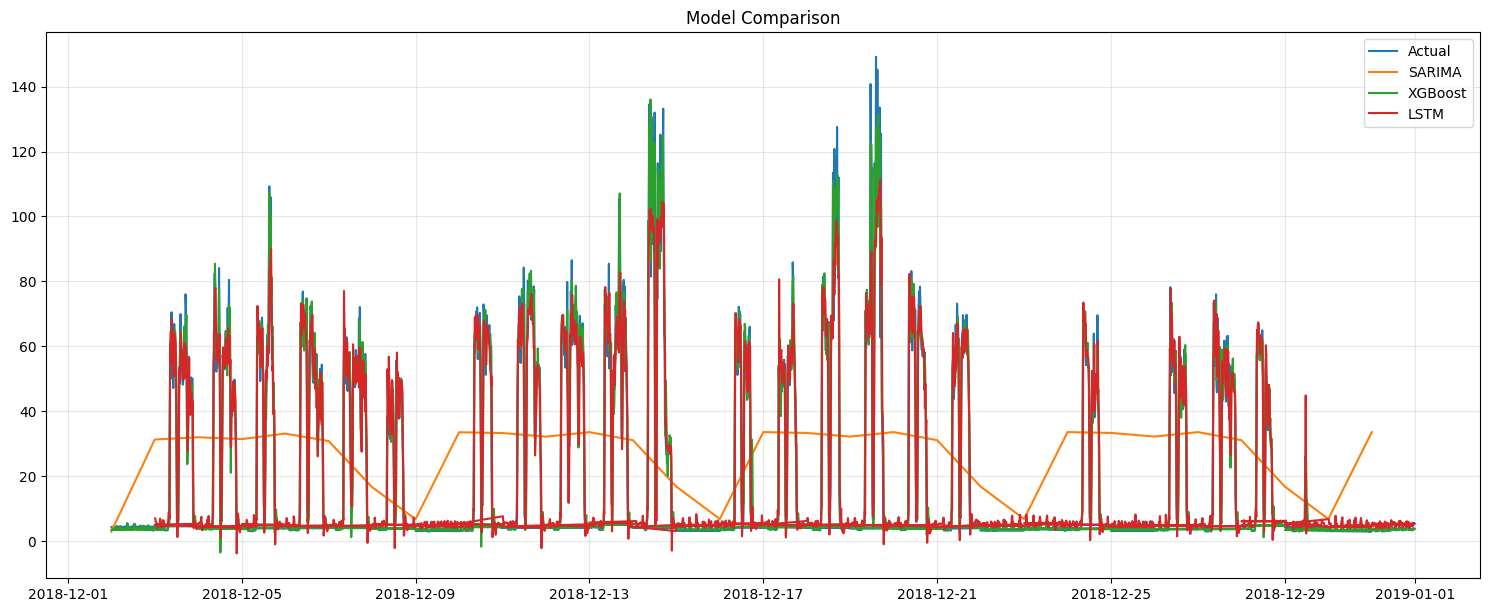

In [65]:
lstm_index = y_test.index[-len(y_pred_inv):]

plt.figure(figsize=(15,6))

plt.plot(test_data.index, test_data.values, label='Actual')
plt.plot(test_sarima_daily.index, sarima_pred_daily, label='SARIMA')
plt.plot(y_test.index, xgb_pred, label='XGBoost')
plt.plot(lstm_index, y_pred_inv, label='LSTM')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.title("Model Comparison")
plt.show()

ผลการทดลองแสดงให้เห็นว่าโมเดล XGBoost มีประสิทธิภาพเหนือกว่าโมเดล SARIMA และ LSTM อย่างมีนัยสำคัญในทุกตัวชี้วัดการประเมินผล

โดย **XGBoost ให้ค่าความคลาดเคลื่อนต่ำที่สุดในทุกเมตริก** ได้แก่ MAE (1.73), RMSE (3.74) และ MAPE (10.22%) ซึ่งสะท้อนถึงความแม่นยำและความเสถียรในการพยากรณ์ที่สูงกว่า ข้อได้เปรียบนี้เกิดจากความสามารถของโมเดลในการเรียนรู้ความสัมพันธ์เชิงไม่เชิงเส้น (nonlinear relationships) และการใช้คุณลักษณะที่สร้างขึ้นจากข้อมูลย้อนหลัง (lag features) ได้อย่างมีประสิทธิภาพ

สำหรับ LSTM ซึ่งถูกออกแบบมาสำหรับข้อมูลลำดับ (sequential data) ให้ผลลัพธ์ในระดับปานกลาง โดยแม้ว่าจะมีประสิทธิภาพดีกว่า SARIMA แต่ยังคงด้อยกว่า XGBoost ทั้งนี้อาจเป็นผลมาจากข้อจำกัดของขนาดข้อมูล และการปรับจูนพารามิเตอร์ที่ยังไม่เพียงพอ

ในขณะที่ **SARIMA มีประสิทธิภาพต่ำที่สุด** โดยเฉพาะค่า MAPE ที่สูงถึง 116% ซึ่งสะท้อนให้เห็นว่าโมเดลเชิงสถิติแบบดั้งเดิมมีข้อจำกัดในการจับรูปแบบข้อมูลที่มีความซับซ้อนและไม่เป็นเชิงเส้นในข้อมูลการใช้พลังงานในภาคอุตสาหกรรม

โดยสรุป แนวทาง Machine Learning โดยเฉพาะ XGBoost มีความเหมาะสมมากที่สุดสำหรับงานพยากรณ์ข้อมูลพลังงานที่มีความถี่สูง

# 6. **Conclusion**  
การศึกษานี้มีวัตถุประสงค์เพื่อเปรียบเทียบประสิทธิภาพของโมเดลพยากรณ์อนุกรมเวลา 3 รูปแบบ ได้แก่ SARIMA, XGBoost และ LSTM สำหรับการทำนายการใช้พลังงานไฟฟ้า (Usage_kWh)

จากผลการทดลองพบว่า **XGBoost** **เป็นโมเดลที่ให้ผลลัพธ์ดีที่สุดในทุกตัวชี้วัด** ทั้ง MAE, RMSE และ MAPE โดยสามารถทำนายได้อย่างแม่นยำและมีความเสถียรสูง สาเหตุหลักมาจากความสามารถของโมเดลในการเรียนรู้ความสัมพันธ์เชิงไม่เชิงเส้น (nonlinear relationships) และการใช้ข้อมูลย้อนหลัง (lag features) ได้อย่างมีประสิทธิภาพ

ในขณะที่ LSTM ซึ่งเป็นโมเดล Deep Learning สำหรับข้อมูลลำดับ (sequential data) ให้ผลลัพธ์อยู่ในระดับปานกลาง โดยสามารถทำผลงานได้ดีกว่า SARIMA แต่ยังไม่สามารถเอาชนะ XGBoost ได้ ทั้งนี้อาจเนื่องมาจากข้อจำกัดของขนาดข้อมูล และการปรับจูนพารามิเตอร์ที่ยังไม่ครอบคลุมเพียงพอ

สำหรับ **SARIMA** ซึ่งเป็นโมเดลเชิงสถิติแบบดั้งเดิม พบว่า**มีประสิทธิภาพต่ำที่สุด** โดยเฉพาะในค่า MAPE ที่สูงมาก แสดงให้เห็นว่าโมเดลไม่สามารถจับรูปแบบที่ซับซ้อนของข้อมูลการใช้พลังงานที่มีความผันผวนและไม่เป็นเชิงเส้นได้ดี

โดยสรุป โมเดลประเภท Machine Learning โดยเฉพาะ XGBoost มีความเหมาะสมมากที่สุดสำหรับการพยากรณ์ข้อมูลการใช้พลังงานในลักษณะนี้ ในอนาคตสามารถพัฒนาต่อยอดได้โดยการเพิ่มตัวแปรภายนอก (เช่น สภาพอากาศ หรือข้อมูลการผลิต) การปรับจูนโมเดล LSTM ให้มีประสิทธิภาพสูงขึ้น หรือการสร้างโมเดลแบบ Hybrid ที่ผสมผสานข้อดีของหลายวิธีเข้าด้วยกัน
